# Data worth example with well that turns off

An attempts at studying the data worth of a model with a pumping well that turns off at some point in time. Two models are calibrated on two different periods, one with the well pumping and with the well pumping and turning off. The data worth is then calculated for both models by looking of the effect of adding and removing data points with the well turning off. The data worth effect is expected to be roughly the same for both models.

## Setup

### Packages

In [1]:
import os
from typing import Literal

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pastas as ps
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import chi2
from tqdm.contrib.concurrent import process_map

import pastas_plugins.dataworth as ppdw

/home/vonkm/repos/pastas-plugins/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data

In [2]:
head = pd.read_csv(
    "../../../pastas/doc/examples/data_notebook_5/head_wellex.csv",
    index_col="Date",
    parse_dates=True,
).squeeze("columns")
rain = (
    pd.read_csv(
        "../../../pastas/doc/examples/data_notebook_5/prec_wellex.csv",
        index_col="Date",
        parse_dates=True,
    )
    .squeeze("columns")
    .multiply(1e3)
)
evap = (
    pd.read_csv(
        "../../../pastas/doc/examples/data_notebook_5/evap_wellex.csv",
        index_col="Date",
        parse_dates=True,
    )
    .squeeze("columns")
    .multiply(1e3)
)
well = (
    pd.read_csv(
        "../../../pastas/doc/examples/data_notebook_5/well_wellex.csv",
        index_col="Date",
        parse_dates=True,
    )
    .squeeze("columns")
    .multiply(-365 / 1e6)
)

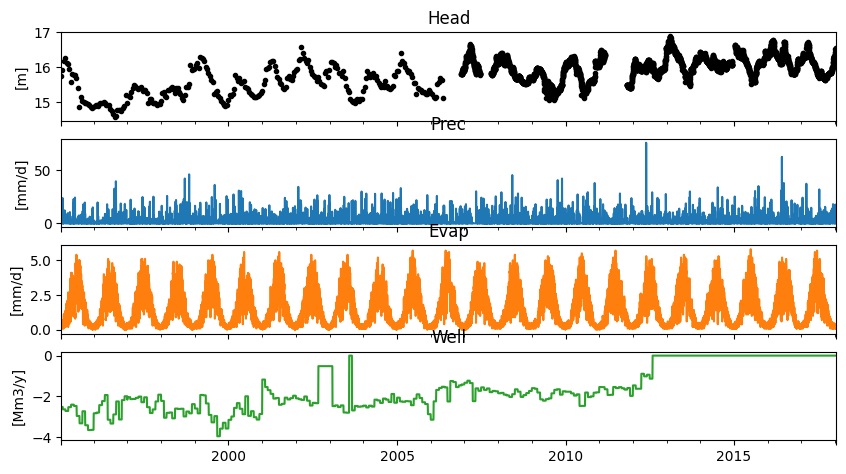

In [3]:
axes = ps.plots.series(
    head,
    [rain, evap, well],
    labels=["[m]", "[mm/d]", "[mm/d]", "[Mm3/y]"],
    figsize=(10, 6),
    hist=False,
)

## Modeling

In [4]:
# Create the time series model
def get_model(
    fit_constant: bool,
    freq_obs: Literal["D", "14D"],
    fix_parameters: bool,
    tmax: pd.Timestamp | None = None,
) -> ps.Model:
    head_s = ps.ts.get_sample_for_freq(head, freq_obs)
    ml = ps.Model(head_s, name="full" if tmax is None else "short")
    rm = ps.RechargeModel(prec=rain, evap=evap, rfunc=ps.Exponential(), name="recharge")
    ml.add_stressmodel(rm)
    settings = {
        "sample_up": "bfill",
        "sample_down": "mean",
        "fill_nan": 0.0,
        "fill_before": "mean",
        "fill_after": 0.0,
    }
    sm = ps.StressModel(well, rfunc=ps.Exponential(), name="well", settings=settings)
    ml.add_stressmodel(sm)
    if fix_parameters:
        ml.set_parameter("constant_d", initial=15.5, vary=False)
        fit_constant = True  # force fit_constant to True if constant_d is fixed
        ml.set_parameter("recharge_A", initial=0.9, vary=False)
        ml.set_parameter("recharge_a", initial=265.0, vary=False)
        ml.set_parameter("recharge_f", initial=-0.9, vary=False)

    tmax = head_s.index[-1] if tmax is None else tmax
    solve_kwargs = {
        "report": False,
        "tmax": tmax,
        "fit_constant": fit_constant,
        "x_scale": "jac",
        "jac": "3-point",
    }
    ml.solve(**solve_kwargs)
    ml.add_noisemodel(ps.ArNoiseModel())
    # if fix_parameters:
    # ml.set_parameter("noise_alpha", initial=60.0, vary=False)
    ml.solve(initial=False, **solve_kwargs)
    return ml

Get model for full period, or for short period up to 2012 (before well was switched off).

In [5]:
# Setttings
fit_constant = True
freq_obs = "14D"
fix_parameters = False
tmax = pd.Timestamp("2012-01-01")

# Create the model for full period
ml_full = get_model(
    fit_constant=fit_constant,
    freq_obs=freq_obs,
    fix_parameters=fix_parameters,
)

# Create the model for short period
ml_short = get_model(
    fit_constant=fit_constant,
    freq_obs=freq_obs,
    fix_parameters=fix_parameters,
    tmax=tmax,
)

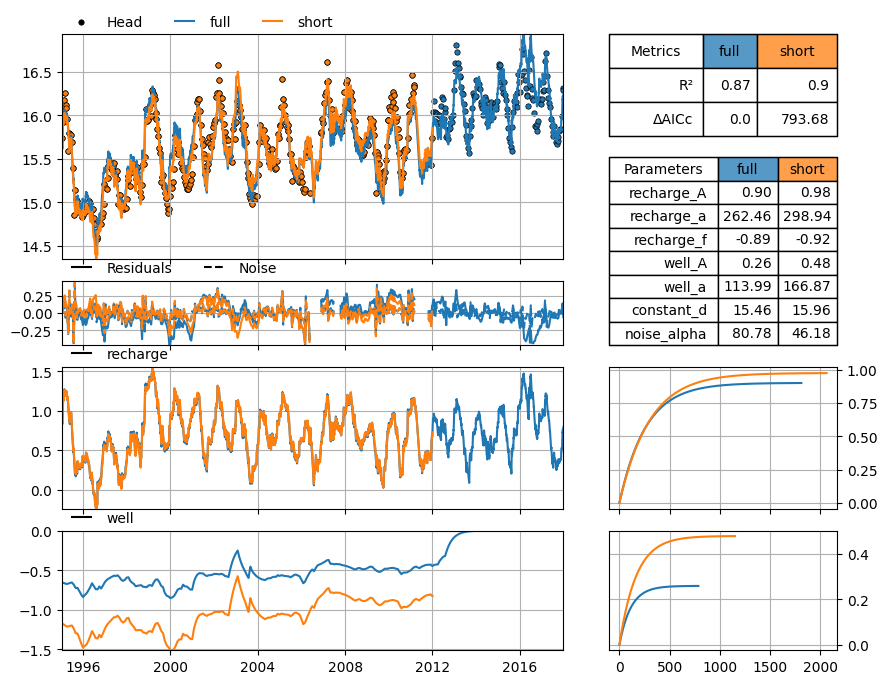

In [6]:
axd = ps.plots.compare([ml_full, ml_short], figsize=(10, 8))

Plot contribution confidence interval for model with data till 2012 and model with all
data. Clearly, including the period of head observations where the well is off is quite
important to estimate the influence of the well.

Text(0.0, 1.0, 'CI width increase: 1.921')

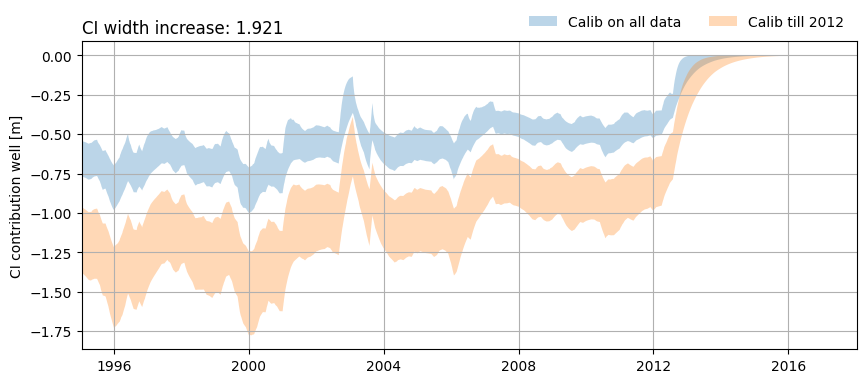

In [7]:
ci_full = ml_full.solver.ci_contribution("well")
ci_short = ml_short.solver.ci_contribution("well", tmax=head.index[-1])

fig, ax = plt.subplots(figsize=(10.0, 4.0))

ax.fill_between(
    ci_full.index,
    ci_full.iloc[:, 0],
    ci_full.iloc[:, 1],
    alpha=0.3,
    label="Calib on all data",
)
ax.fill_between(
    ci_short.index,
    ci_short.iloc[:, 0],
    ci_short.iloc[:, 1],
    alpha=0.3,
    label="Calib till 2012",
)
ax.legend(bbox_to_anchor=(1, 1), loc="lower right", frameon=False, ncol=2)
ax.set_ylabel("CI contribution well [m]")
ax.set_xlim(head.index[0], head.index[-1])
ax.grid(True)

ci_increase = f"{(ci_short.diff(axis=1).iloc[:, 1].mean() / ci_full.diff(axis=1).iloc[:, 1].mean()):.3f}"
ax.set_title("CI width increase: " + ci_increase, loc="left")

## Data Worth Analysis

### Full Model

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_52263/3214302340.py:8: SyntaxWarning: invalid escape sequence '\D'
  dwdf.columns = ["$\Delta$ gen. std. err. (%)"] + [
/tmp/ipykernel_52263/3214302340.py:9: SyntaxWarning: invalid escape sequence '\D'
  f"$\Delta\sigma$ {name} (%)"
Data Worth (existing obs): 100%|██████████| 542/542 [00:06<00:00, 88.92it/s] 


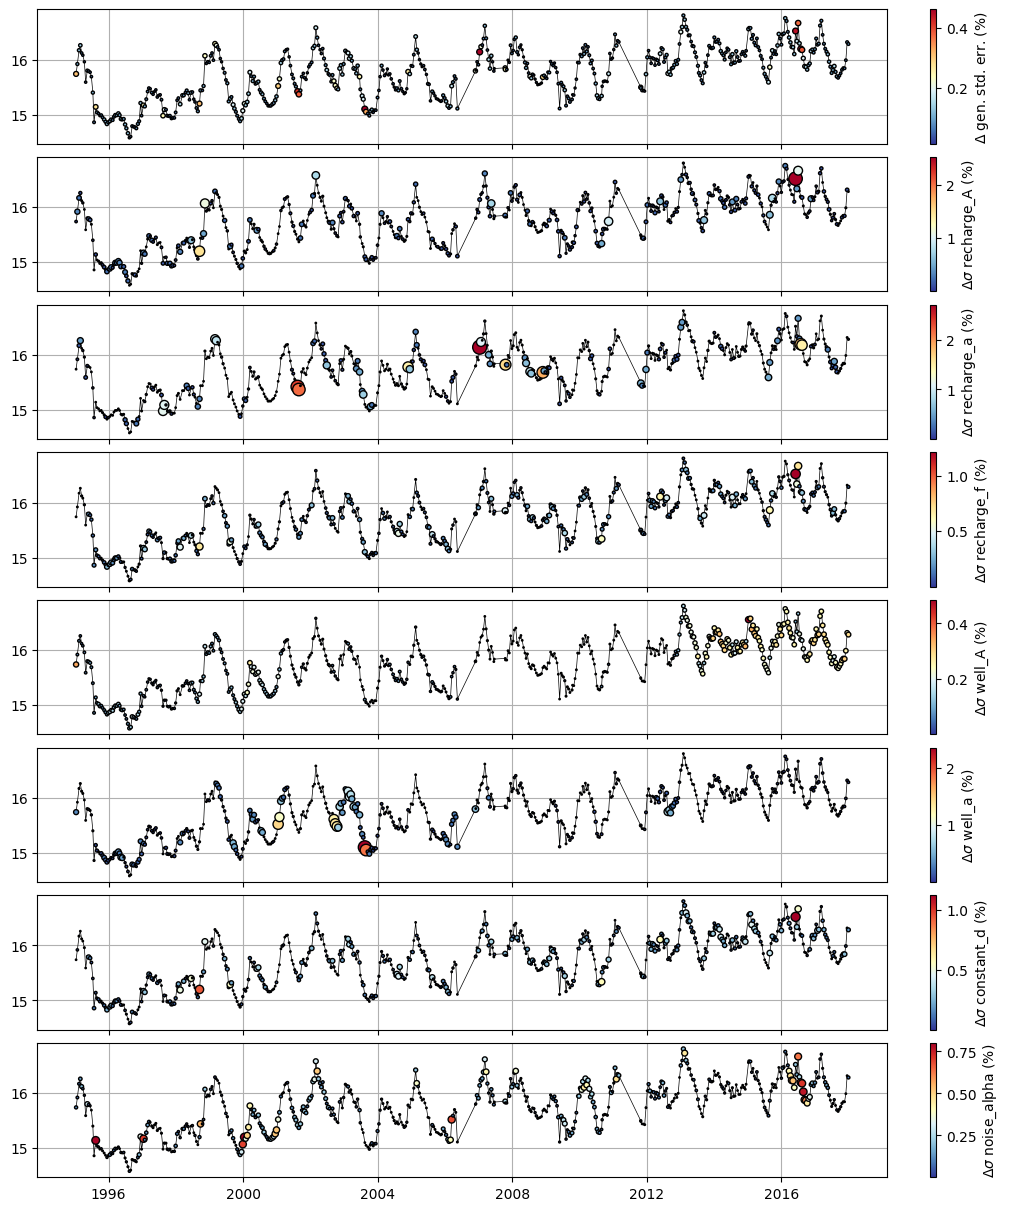

In [8]:
dw = ppdw.DataWorth(ml_full)
dwdf = dw.data_worth_per_observation()
N = ml_full.parameters.vary.sum()
dwdf.iloc[:, 0] = (np.exp(dwdf.iloc[:, 0] / (2 * N)) - 1) * 100
dwdf.iloc[:, 1:] = ((1 + dwdf.iloc[:, 1:]).pow(0.5) - 1) * 100

# update column names accordingly
dwdf.columns = ["$\Delta$ gen. std. err. (%)"] + [
    f"$\Delta\sigma$ {name} (%)"
    for name, row in ml_full.parameters.iterrows()
    if row.at["vary"]
]

axes = ppdw.plot_data_worth_series(ml_full.observations(), dwdf)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_52263/3919134881.py:1: SyntaxWarning: invalid escape sequence '\D'
  ax = ppdw.plot_data_worth_heatmap(dwdf["$\Delta\sigma$ well_A (%)"])


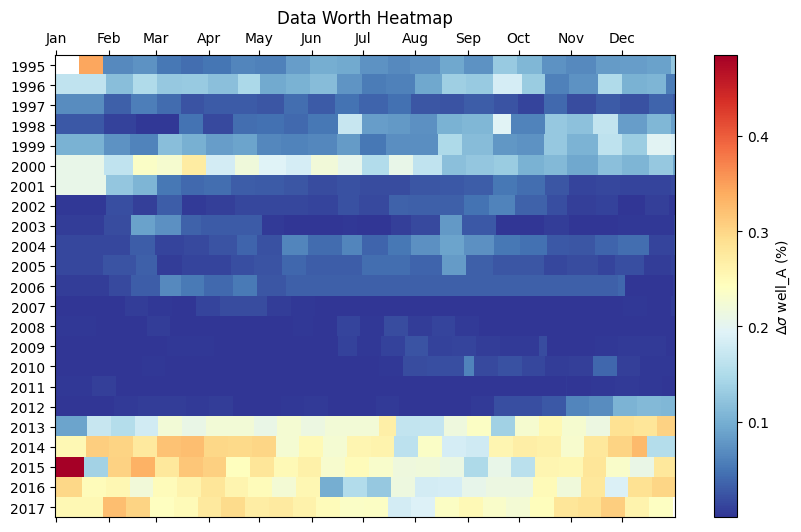

In [9]:
ax = ppdw.plot_data_worth_heatmap(dwdf["$\Delta\sigma$ well_A (%)"])

Given model solved on all data, what would the increase in uncertainty be if we only
included data from before 2012.

In [10]:
# Calculate data worth with mask
obs = ml_full.observations()
mask = pd.Series(index=obs.index, data=True)
mask.loc["2012-01-01":] = False
# dwdf_mask = dw.data_worth(mask=mask)


mlc_full = ml_full.copy()
mlc_full.solver.pcov = ml_full.solver.pcov.copy()
mlc_full.solver.pcov.loc[:, :] = mlc_full.solver.get_covariances(
    ml_full.solver.result.jac[mask.values], ml_full.solver.result.cost
)
mlc_full._parameters.loc[mlc_full.parameters.vary, "stderr"] = np.sqrt(
    np.diag(mlc_full.solver.pcov)
)
cic_full = mlc_full.solver.ci_contribution("well", tmax=head.index[-1])

Text(0.0, 1.0, 'CI width ratio: 3.337')

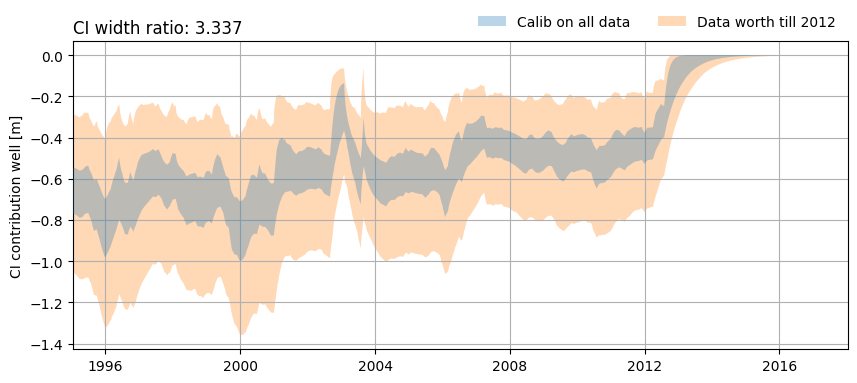

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    ci_full.index,
    ci_full.iloc[:, 0],
    ci_full.iloc[:, 1],
    alpha=0.3,
    label="Calib on all data",
    zorder=5,
)
ax.fill_between(
    cic_full.index,
    cic_full.iloc[:, 0],
    cic_full.iloc[:, 1],
    alpha=0.3,
    label="Data worth till 2012",
)
ax.legend(bbox_to_anchor=(1.0, 1.0), loc="lower right", frameon=False, ncol=3)
ax.set_ylabel("CI contribution well [m]")
ax.set_xlim(head.index[0], head.index[-1])
ax.grid(True)

ci_increase = f"{(cic_full.diff(axis=1).iloc[:, 1].mean() / ci_full.diff(axis=1).iloc[:, 1].mean()):.3f}"
ax.set_title("CI width ratio: " + ci_increase, loc="left")

### Short Model

Given the model solved on the data up to 2012, what would the decrease in uncertainty be if we included all data.

In [12]:
# get existing observations and combine with new observations
obs_calib = ml_short.observations()
new_observations = ml_full.observations().loc[obs_calib.index[-1] :]
# mask out existing observations from new_observations to avoid duplicates
if obs_calib.index.intersection(new_observations.index).size > 0:
    new_observations = new_observations.loc[
        ~new_observations.index.isin(obs_calib.index)
    ]

obs = pd.concat([obs_calib, new_observations], axis=0).sort_index()

# recompute Jacobian and observation noise covariance
dw_short = ppdw.DataWorth(ml_short)
objfun_target = "noise"  # "residuals"
Jadj = dw_short.recompute_jacobian(obs, objfun_target=objfun_target)
C_eps = dw_short.observation_noise_covariance(obs=obs, objfun_target=objfun_target)
pcov = dw_short.compute_covariance(Jadj, C_eps)

mlc_short = ml_short.copy()
mlc_short.solver.pcov = pd.DataFrame(
    pcov, index=ml_short.solver.pcov.index, columns=ml_short.solver.pcov.columns
)
mlc_short._parameters.loc[mlc_short.parameters.vary, "stderr"] = np.sqrt(
    np.diag(mlc_short.solver.pcov)
)
cic_short = mlc_short.solver.ci_contribution("well", tmax=head.index[-1])

Text(0.0, 1.0, 'CI width ratio: 0.911')

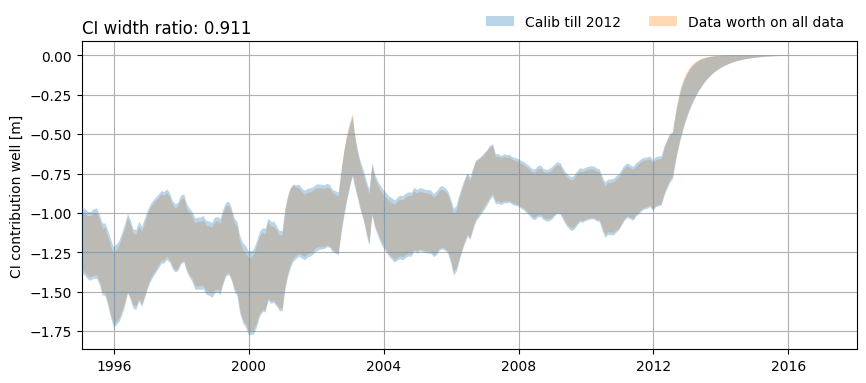

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    ci_short.index,
    ci_short.iloc[:, 0],
    ci_short.iloc[:, 1],
    alpha=0.3,
    label="Calib till 2012",
    zorder=5,
)
ax.fill_between(
    cic_short.index,
    cic_short.iloc[:, 0],
    cic_short.iloc[:, 1],
    alpha=0.3,
    label="Data worth on all data",
)
ax.legend(bbox_to_anchor=(1.0, 1.0), loc="lower right", frameon=False, ncol=2)
ax.set_ylabel("CI contribution well [m]")
ax.set_xlim(head.index[0], head.index[-1])
ax.grid(True)
ci_increase = f"{(cic_short.diff(axis=1).iloc[:, 1].mean() / ci_short.diff(axis=1).iloc[:, 1].mean()):.3f}"
ax.set_title("CI width ratio: " + ci_increase, loc="left")

### Response Surface Analysis

In [14]:
ps.set_log_level("ERROR")


def _compute_sse_worker(
    ml_template: ps.Model,
    A_idx: int,
    a_idx: int,
    A_val: float,
    a_val: float,
) -> tuple[int, int, float]:
    """Worker function to compute SSE for a single point (no globals)."""
    ml_copy = ml_template.copy()

    # Compute SSE
    ml_copy.set_parameter("well_A", optimal=A_val)
    ml_copy.set_parameter("well_a", optimal=a_val)
    sse = ml_copy.stats.sse()

    return A_idx, a_idx, sse


def compute_response_surface(
    ml: ps.Model,
    p_true: pd.Series | None = None,
    N: int = 100,
    A_min: float | None = None,
    A_max: float | None = None,
    a_min: float | None = None,
    a_max: float | None = None,
    max_workers: int | None = None,
) -> pd.DataFrame:
    """Compute response surface for well parameters using parallel processing.

    Parameters
    ----------
    ml : ps.Model
        Pastas model template
    p_true : pd.Series | None
        Series with true parameter values, indexed by parameter name
    N : int
        Number of points for each parameter axis
    A_min, A_max, a_min, a_max : float, optional
        Parameter bounds. If None, uses model defaults
    max_workers : int, optional
        Number of workers. If None, uses cpu_count()

    Returns
    -------
    pd.DataFrame
        DataFrame with SSE
    """
    # Set defaults
    max_workers = max_workers or os.cpu_count()

    mlc = ml.copy()
    if p_true is not None:
        for p_name, p_val in p_true.items():
            mlc.set_parameter(p_name, optimal=p_val)

    # Get parameter bounds
    A_min = mlc.parameters.at["well_A", "pmin"] if A_min is None else A_min
    A_max = mlc.parameters.at["well_A", "pmax"] if A_max is None else A_max
    a_min = mlc.parameters.at["well_a", "pmin"] if a_min is None else a_min
    a_max = mlc.parameters.at["well_a", "pmax"] if a_max is None else a_max

    # Create parameter ranges
    A_range = np.linspace(start=A_min, stop=A_max, num=N)
    a_range = np.linspace(start=a_min, stop=a_max, num=N)

    # Generate tasks
    tasks = [
        (mlc, A_idx, a_idx, A_val, a_val)
        for A_idx, A_val in enumerate(A_range)
        for a_idx, a_val in enumerate(a_range)
    ]

    # Compute in parallel with progress bar
    results = np.empty((N, N))
    task_results = process_map(
        _compute_sse_worker,
        *zip(*tasks),
        max_workers=max_workers,
        desc=f"Computing SSE for {ml.name}",
        chunksize=100,
    )
    for A_idx, a_idx, sse in task_results:
        results[A_idx, a_idx] = sse

    # Create xarray Dataset
    df = pd.DataFrame(
        results,
        index=pd.Index(A_range, name="A"),
        columns=pd.Index(a_range, name="a"),
    )

    return df

In [15]:
N = 50
A_max = 0.7
a_max = 300
rs_full = compute_response_surface(
    ml_full,
    p_true=ml_full.parameters["optimal"],
    N=N,
    A_max=A_max,
    a_max=a_max,
)
rs_short = compute_response_surface(
    ml_short,
    p_true=ml_short.parameters["optimal"],
    N=N,
    A_max=A_max,
    a_max=a_max,
)

Computing SSE for short: 100%|██████████| 2500/2500 [00:40<00:00, 61.77it/s] 


In [16]:
cmap = plt.get_cmap("viridis")
min_val = min(np.min(rs_full.values), np.min(rs_short.values))
max_val = max(np.max(rs_full.values), np.max(rs_short.values))
log_min = np.floor(np.log10(min_val))
log_max = np.ceil(np.log10(max_val))
levels = np.logspace(log_min, log_max, int(log_max - log_min) + 1)
norm = mpl.colors.LogNorm(vmin=10**log_min, vmax=10**log_max)
# norm = mpl.colors.Normalize(vmin=10**log_min, vmax=10**log_max)


def plot_response_surface(ax: plt.Axes, rs: pd.DataFrame, title: str) -> None:
    """Plot response surface from DataFrame."""
    ax.pcolormesh(rs.columns, rs.index, rs.values, cmap=cmap, norm=norm)
    c = ax.contour(
        rs.columns,
        rs.index,
        rs.values,
        colors="w",
        levels=levels,
        linewidths=[0.5],
    )
    ax.clabel(c, fontsize=7, fmt="%1.0e")
    ax.set_title(title)
    ax.set_ylabel(rs.index.name)
    ax.set_xlabel(rs.columns.name)
    ax.grid(False)


def draw_param_ci(ax: plt.Axes, ml: ps.Model, label: str, color: str) -> None:
    """Draw 95% confidence interval for well parameters."""
    ax.errorbar(
        ml.parameters.at["well_a", "optimal"],
        ml.parameters.at["well_A", "optimal"],
        xerr=ml.parameters.at["well_a", "stderr"] * 1.96,
        yerr=ml.parameters.at["well_A", "stderr"] * 1.96,
        color=color,
        label=label,
    )


def draw_ellipse_ci(
    ax: plt.Axes, ml: ps.Model, label: str, color: str, **kwargs
) -> None:
    """Draw 95% confidence ellipse for well parameters."""

    cov = ml.solver.pcov.loc[["well_a", "well_A"], ["well_a", "well_A"]].values
    mean = ml.parameters.loc[["well_a", "well_A"], "optimal"].values

    # Calculate eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Calculate angle for Matplotlib Ellipse (needs degrees)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    # CORRECTED: Use Chi-square distribution for 2D confidence region
    # chi2.ppf(0.95, 2) is approx 5.991. The square root is approx 2.4477.
    scale = np.sqrt(chi2.ppf(0.95, 2))
    width, height = 2 * scale * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor="none",  # changed from None to color to ensure visibility if facecolor has alpha
        facecolor=color,  # frequently ellipses are transparent inside, adjust as needed
        label=label,
        **kwargs,
    )
    ax.add_patch(ellipse)


def draw_param_cross_ci(
    ax: plt.Axes, ml: ps.Model, label: str, color: str, **kwargs
) -> None:
    """Draw 95% confidence cross for well parameters using eigenvectors."""

    cov = ml.solver.pcov.loc[["well_a", "well_A"], ["well_a", "well_A"]].values
    mean = ml.parameters.loc[["well_a", "well_A"], "optimal"].values

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # CORRECTED scale for 2D
    scale = np.sqrt(chi2.ppf(0.95, 2))
    width, height = 2 * scale * np.sqrt(eigvals)

    # OPTIMIZED: Use eigenvectors directly instead of trig functions
    v_major = eigvecs[:, 0] * (width / 2)
    v_minor = eigvecs[:, 1] * (height / 2)

    # Major axis
    ax.plot(
        [mean[0] - v_major[0], mean[0] + v_major[0]],
        [mean[1] - v_major[1], mean[1] + v_major[1]],
        color=color,
        label=label,
        **kwargs,
    )
    # Minor axis
    ax.plot(
        [mean[0] - v_minor[0], mean[0] + v_minor[0]],
        [mean[1] - v_minor[1], mean[1] + v_minor[1]],
        color=color,
        **kwargs,
    )

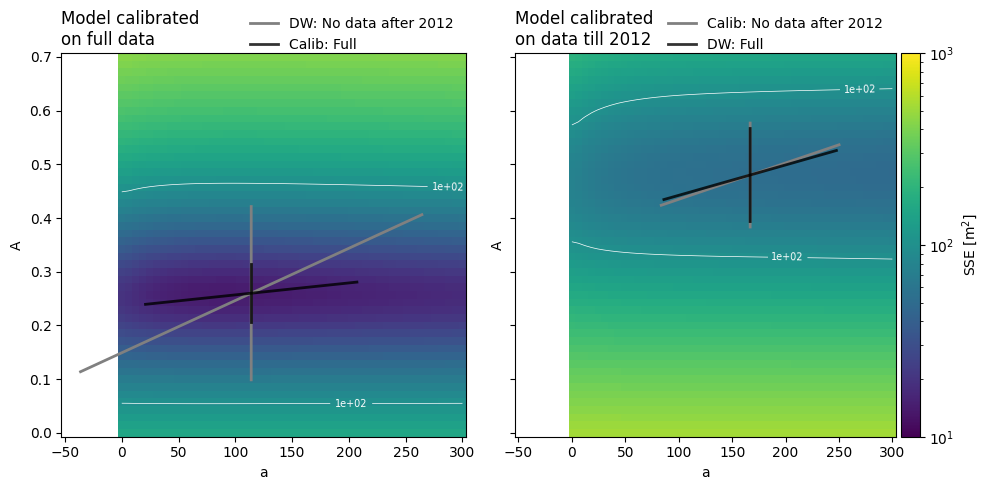

In [17]:
mosaic = [["full", "short"]]
fig, axd = plt.subplot_mosaic(
    mosaic,
    figsize=(10.0, 5.0),
    layout="tight",
    sharey=True,
    sharex=True,
)

plot_response_surface(axd["full"], rs_full, "")
plot_response_surface(axd["short"], rs_short, "")

# draw_param_ci(axd["full"], mlc_full, label="DW: No data after 2012", color="gray")
# draw_param_ci(axd["full"], ml_full, label="Calib: Full", color="black")
# draw_param_ci(axd["short"], ml_short, label="Calib: No data after 2012", color="gray")
# draw_param_ci(axd["short"], mlc_short, label="DW: Full", color="black")

# draw_ellipse_ci(axd["full"], mlc_full, label="DW: No data after 2012", color="gray", alpha=0.5)
# draw_ellipse_ci(axd["full"], ml_full, label="Calib: Full", color="black", alpha=0.5)
# draw_ellipse_ci(axd["short"], ml_short, label="Calib: No data after 2012", color="gray", alpha=0.5)
# draw_ellipse_ci(axd["short"], mlc_short, label="DW: Full", color="black", alpha=0.5)

draw_param_cross_ci(
    axd["full"], mlc_full, label="DW: No data after 2012", color="gray", linewidth=2
)
draw_param_cross_ci(
    axd["full"], ml_full, label="Calib: Full", color="black", linewidth=2, alpha=0.8
)
draw_param_cross_ci(
    axd["short"], ml_short, label="Calib: No data after 2012", color="gray", linewidth=2
)
draw_param_cross_ci(
    axd["short"], mlc_short, label="DW: Full", color="black", linewidth=2, alpha=0.8
)

axd["full"].set_title("Model calibrated\non full data", loc="left")
axd["short"].set_title("Model calibrated\non data till 2012", loc="left")
axd["full"].legend(bbox_to_anchor=(1, 0.97), loc="lower right", frameon=False, ncol=1)
axd["short"].legend(bbox_to_anchor=(1, 0.97), loc="lower right", frameon=False, ncol=1)

div = make_axes_locatable(axd["short"])
cax = div.append_axes("right", size="5%", pad=0.05)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, label="SSE [m$^2$]")